# Watching the horizon effect: one 2° encounter, five ways

`orca_vs_mvp_vo.ipynb` reports that plain ORCA spends **1564 s** locked on parallel tracks in a 2°
crossing where DH-ORCA spends 340 s. This notebook is that one encounter, drawn.

**The horizon effect.** ORCA forbids the velocities that cause an incursion within `τ`, and nothing
else. When two aircraft at similar speeds converge at a shallow angle, the *cheapest* way to satisfy
that constraint is to turn until the tracks are **parallel** — the closing rate goes to zero, the
conflict slides just past `τ`, and ORCA is content. The pair then flies side by side at exactly the
protected-zone radius. No separation is lost. Nothing is resolved either: neither aircraft is going
where it wanted to, and nothing in the algorithm has any reason to stop.

DH-ORCA adds a second, longer horizon whose constraint is built from the **untruncated** cone, and
that constraint cannot be satisfied by going parallel — it requires a non-zero closing component
along the line between the aircraft, which is exactly what makes the paths cross. Its cost is paid
only on the encounters where the ownship's own goal actually crosses the other's track.

**One pinned encounter throughout.** Two M600s, 2° crossing, zero design miss, `rpz = 50 m`,
`tlos = 90 s`, lookahead `60 s`. **No navigation noise and no comm model** — the lock is a
deterministic property of the resolution logic, and noise would only blur the picture. `t_max` is
raised to 3000 s so a lock has room to run its full length rather than being truncated.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from opencdarr import (
    DHORCA,
    MVP,
    ORCA,
    VO,
    FTR,
    M600,
    Agent,
    AircraftState,
    ORCARevert,
    StateBased,
    create_conflict,
    run_fleet,
)
from opencdarr.viz import extract_tracks

RPZ = 50.0  # m
TAU = 60.0  # s — detection lookahead, ORCA's horizon, DH-ORCA's t_conflict
T_CROSS = 180.0  # s — DH-ORCA's long horizon
SPEED = 10.2889  # m/s (~20 kt)
DPSI = 5.0  # deg — the crossing angle this notebook is about
DT = 0.5  # s

DH = DHORCA(margin=1.0, t_conflict=TAU, t_cross=T_CROSS, v_max=M600.v_max)

STACKS = {
    "no resolution": (None, None),
    "MVP + FTR": (MVP(margin=1.0), FTR()),
    "VO + FTR": (VO(margin=1.0), FTR()),
    "ORCA + ORCARevert": (ORCA(margin=1.0, t_horizon=TAU, v_max=M600.v_max),
                          ORCARevert(t_horizon=TAU)),
    "DH-ORCA + ORCARevert": (DH, ORCARevert(t_horizon=T_CROSS)),
    "DH-ORCA + FTR": (DH, FTR()),
}
COLOUR = {
    "no resolution": "0.6",
    "MVP + FTR": "tab:blue",
    "VO + FTR": "tab:orange",
    "ORCA + ORCARevert": "tab:green",
    "DH-ORCA + ORCARevert": "tab:red",
    "DH-ORCA + FTR": "tab:purple",
}

In [23]:
def fly(resolver, recovery):
    """The pinned 2° encounter under one stack, as (outcome, tracks)."""
    own = AircraftState(id="OWN", lat=52.0, lon=4.0, trk=0.0, gs=SPEED)
    intr = create_conflict(own, intr_id="INT", dpsi=DPSI, dcpa=0.0, tlos=90.0, rpz=RPZ, side=1)
    out = run_fleet(
        [Agent(own, M600), Agent(intr, M600)],
        rpz=RPZ, t_lookahead=TAU, dt=DT,
        detector=StateBased(), resolver=resolver, recovery=recovery,
        t_max=3000.0, done_timeout=10.0, record=True,
    )
    return out, extract_tracks(out)


runs = {label: fly(res, rec) for label, (res, rec) in STACKS.items()}

# the intruder's position relative to the ownship. The ownship's nominal track is due north, so
# this frame is already the natural one: east is cross-track, north is along-track.
relative = {label: tr.tracks[1] - tr.tracks[0] for label, (_, tr) in runs.items()}

print(f"{'stack':21s} {'t_end':>8s} {'min sep':>8s} {'end sep':>8s} {'own path':>9s} "
      f"{'max off-route':>14s}")
for label, (out, tr) in runs.items():
    own_track = tr.tracks[0]
    flown = float(np.sum(np.hypot(*np.diff(own_track, axis=0).T)))
    # the ownship's nominal is due north, so its east coordinate *is* its cross-track error
    off_route = float(np.abs(own_track[:, 0]).max())
    print(f"{label:21s} {tr.times[-1]:7.1f}s {out.min_sep:7.1f}m "
          f"{np.hypot(*relative[label][-1]):7.1f}m {flown / 1000:8.2f}km "
          f"{off_route:13.1f}m")

stack                    t_end  min sep  end sep  own path  max off-route
no resolution           211.0s     0.0m    58.6m     2.17km           0.0m
MVP + FTR               155.5s    50.2m    50.9m     1.57km           1.1m
VO + FTR                186.5s    50.8m    51.5m     1.94km          15.0m
ORCA + ORCARevert       371.0s    50.0m    51.1m     3.84km          96.8m
DH-ORCA + ORCARevert    187.0s    50.0m    51.1m     1.95km          14.4m
DH-ORCA + FTR           186.0s    50.0m    50.8m     1.94km          14.8m


`own path` is how far the ownship actually flies before the encounter clears, and `max off-route`
is how far it is pushed off its nominal line. Note which one separates the stacks: the deviation is
tens of metres for everyone, but the **distance flown** differs by more than four times. The lock is
not a route-efficiency problem in the usual sense — the aircraft are not flying in circles, they are
flying straight, in the wrong formation, for a long time.

## The relative geometry — where the lock is visible

The intruder's position **relative to the ownship**, with the 50 m protected zone drawn as a circle.
This is the right frame for a shallow crossing: in absolute coordinates the two aircraft fly nearly
identical multi-kilometre lines and the picture is unreadable, whereas here the whole encounter is a
single path that has to get from the start point, around the circle, and out the other side.

Colour is **absolute time on one scale shared by all six panels**, so it is comparable across them —
which is most of the point. Only ORCA's path reaches the top of the scale; every other stack is
finished while its trace is still dark. A lock shows up as colour piling up in one place: the
relative position stops moving, and hundreds of seconds are spent in a spot a few metres across.

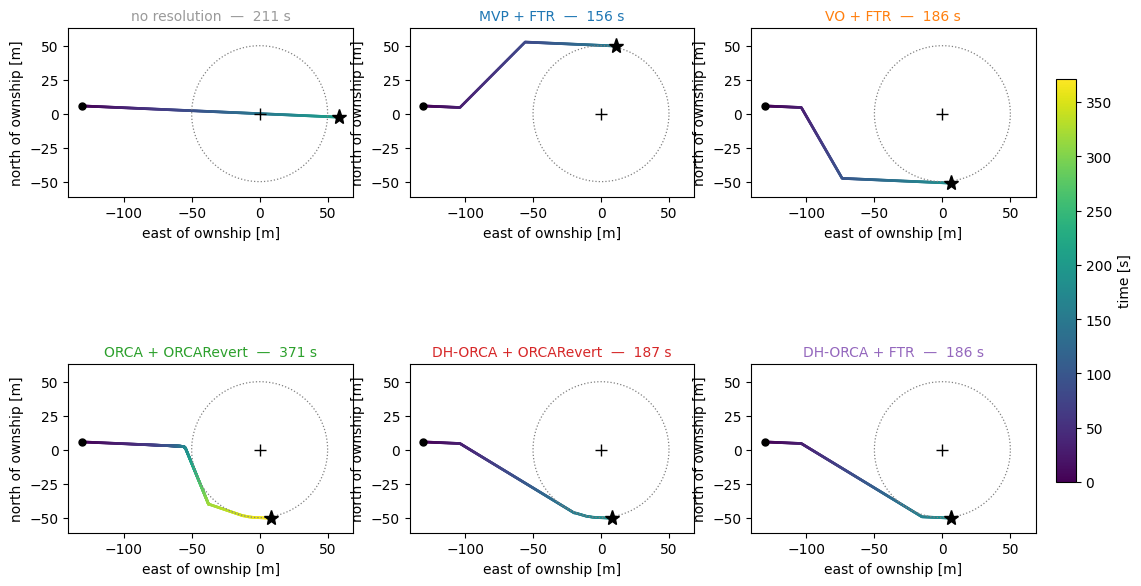

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(13.0, 8.0))
theta = np.linspace(0, 2 * np.pi, 200)

t_max = max(tr.times[-1] for _, tr in runs.values())  # one colour scale for every panel
lo_e = min(rel[:, 0].min() for rel in relative.values())
hi_e = max(rel[:, 0].max() for rel in relative.values())
lo_n = min(rel[:, 1].min() for rel in relative.values())
hi_n = max(rel[:, 1].max() for rel in relative.values())

for ax, (label, rel) in zip(axes.ravel(), relative.items()):
    times = runs[label][1].times
    ax.plot(RPZ * np.cos(theta), RPZ * np.sin(theta), color="0.5", lw=0.9, ls=":")
    dots = ax.scatter(rel[:, 0], rel[:, 1], c=times, cmap="viridis", s=4, linewidths=0,
                      vmin=0.0, vmax=t_max)
    ax.plot(rel[0, 0], rel[0, 1], "o", color="k", ms=5)  # start
    ax.plot(rel[-1, 0], rel[-1, 1], "*", color="k", ms=11)  # end
    ax.plot(0, 0, "+", color="k", ms=9)  # the ownship, at the origin of its own frame
    ax.set_aspect("equal")
    ax.set_xlim(lo_e - 10, hi_e + 10)
    ax.set_ylim(lo_n - 10, hi_n + 10)
    ax.set_title(f"{label}  —  {times[-1]:.0f} s", fontsize=10, color=COLOUR[label])
    ax.set_xlabel("east of ownship [m]")
    ax.set_ylabel("north of ownship [m]")

fig.colorbar(dots, ax=axes, label="time [s]", fraction=0.02, pad=0.02)
fig.savefig("parallel_lock_relative.png", dpi=150, bbox_inches="tight")
plt.show()

## The tracks, which is where the mechanism is

The two aircraft's ground tracks against time. The nominal tracks are 0° and 2°; the grey band marks
tracks within 5° of parallel, the paper's own lock criterion (§7.4).

Watch what each resolver converges to. A pair that has gone **parallel** shows up as the two lines
meeting — both aircraft flying the *same* track, splitting the 2° difference. A pair that is going to
cross keeps them apart.

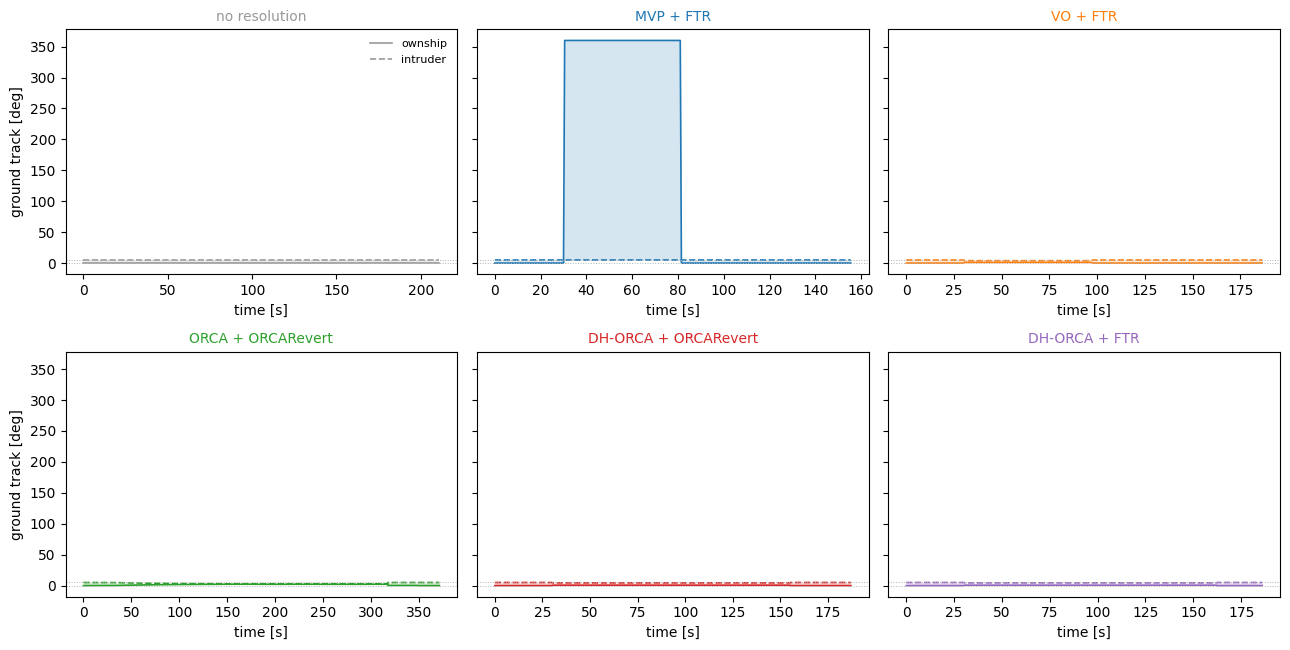

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(13.0, 6.6), sharey=True)

for ax, (label, (out, tr)) in zip(axes.ravel(), runs.items()):
    trk_a = np.array([f.states[0].trk for f in out.frames])
    trk_b = np.array([f.states[1].trk for f in out.frames])
    ax.fill_between(tr.times, np.minimum(trk_a, trk_b), np.maximum(trk_a, trk_b),
                    color=COLOUR[label], alpha=0.18, lw=0)
    ax.plot(tr.times, trk_a, color=COLOUR[label], lw=1.2, label="ownship")
    ax.plot(tr.times, trk_b, color=COLOUR[label], lw=1.2, ls="--", label="intruder")
    ax.axhline(0.0, color="0.7", lw=0.7, ls=":")
    ax.axhline(DPSI, color="0.7", lw=0.7, ls=":")
    ax.set_title(label, fontsize=10, color=COLOUR[label])
    ax.set_xlabel("time [s]")
    # ax.set_ylim(-1.0, 3.0)
axes[0, 0].set_ylabel("ground track [deg]")
axes[1, 0].set_ylabel("ground track [deg]")
axes[0, 0].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig("parallel_lock_tracks.png", dpi=150)
plt.show()

The shaded band between the two lines is the **track difference**: it is the closing geometry. Where
the band pinches shut, the aircraft are parallel and the relative position stops moving — that is
the lock, and it is why the encounter takes as long as it does.

Below, that difference and the separation, on one axes per quantity so the stacks compare directly.
Note that the paper's 5° parallel threshold is not drawn: at a **2° crossing the entire encounter is
inside it by construction**, which is exactly why the threshold alone cannot identify a lock and the
*duration* has to be the measure. What distinguishes the stacks is how long the left panel sits at
**zero** — ORCA holds it there from t ≈ 300 s to t ≈ 1200 s; DH-ORCA never reaches it at all,
holding a deliberate ~1° difference until the crossing is done.

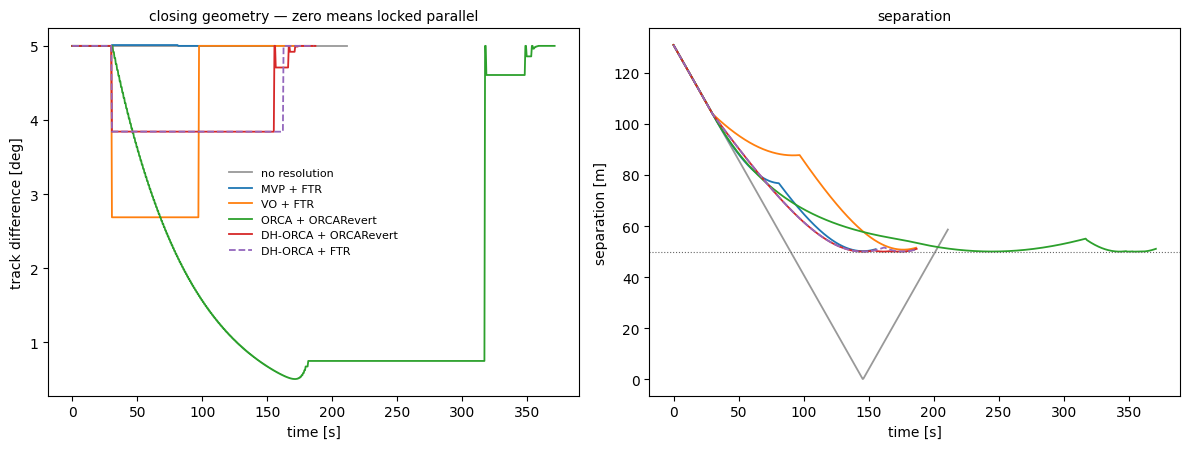

In [26]:
fig, (ax_d, ax_s) = plt.subplots(1, 2, figsize=(12.0, 4.6))

for label, (out, tr) in runs.items():
    dtrk = np.array([
        abs((f.states[0].trk - f.states[1].trk + 180.0) % 360.0 - 180.0) for f in out.frames
    ])
    style = "--" if label == "DH-ORCA + FTR" else "-"
    ax_d.plot(tr.times, dtrk, style, color=COLOUR[label], lw=1.3, label=label)
    ax_s.plot(tr.times, tr.separation, style, color=COLOUR[label], lw=1.3, label=label)

ax_d.set_xlabel("time [s]")
ax_d.set_ylabel("track difference [deg]")
ax_d.set_title("closing geometry — zero means locked parallel", fontsize=10)
# ax_d.set_ylim(0, 2.6)
ax_d.legend(frameon=False, fontsize=8)

ax_s.axhline(RPZ, color="0.4", lw=0.8, ls=":")
ax_s.set_xlabel("time [s]")
ax_s.set_ylabel("separation [m]")
ax_s.set_title("separation", fontsize=10)
# ax_s.set_ylim(0, 90)

fig.tight_layout()
fig.savefig("parallel_lock_timeseries.png", dpi=150)
plt.show()

## The absolute tracks, for scale

The same runs in the ground frame. The axes are deliberately **not** equal-aspect: the along-track
extent is kilometres and the cross-track deviation is tens of metres, so an honest 1:1 plot would be
a horizontal line. The point of this figure is only the *length* of each run — how far down-track the
pair gets before the encounter clears.

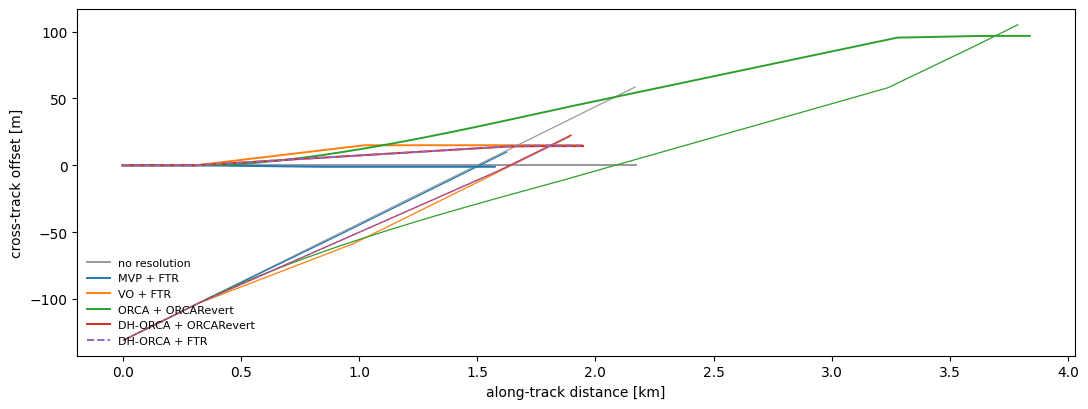

In [27]:
fig, ax = plt.subplots(figsize=(11.0, 4.2))

for label, (out, tr) in runs.items():
    style = "--" if label == "DH-ORCA + FTR" else "-"
    for k, width in ((0, 1.4), (1, 0.9)):  # ownship solid-ish, intruder thinner
        ax.plot(tr.tracks[k][:, 1] / 1000.0, tr.tracks[k][:, 0], style,
                color=COLOUR[label], lw=width, label=label if k == 0 else None)

ax.set_xlabel("along-track distance [km]")
ax.set_ylabel("cross-track offset [m]")
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig("parallel_lock_ground.png", dpi=150)
plt.show()

In [28]:
# How long each stack holds the pair inside the paper's parallel criterion (§7.4, simplified to a
# pair): tracks within 5 deg, same direction, range under 1.5 * rpz.
#
# The no-resolution reference is reported but is NOT a lock: a 2 deg crossing is *already* within
# 5 deg of parallel, so the criterion flags it trivially — and that pair is converging to a
# collision, not holding station. The criterion only means "locked" for a stack that is maintaining
# separation, which is why the row is printed separately.
print(f"{'stack':21s} {'locked':>9s} {'of run':>8s} {'longest stretch':>17s}")
for label, (out, tr) in runs.items():
    locked = np.array([
        abs((f.states[0].trk - f.states[1].trk + 180.0) % 360.0 - 180.0) < 5.0
        and tr.separation[i] < 1.5 * RPZ
        for i, f in enumerate(out.frames)
    ])
    longest = best = 0
    for flag in locked:  # longest contiguous stretch inside the criterion
        best = best + 1 if flag else 0
        longest = max(longest, best)
    note = "   <- geometry, not a lock" if label == "no resolution" else ""
    print(f"{label:21s} {locked.sum() * DT:8.1f}s {locked.mean():7.1%} "
          f"{longest * DT:16.1f}s{note}")

stack                    locked   of run   longest stretch
no resolution              0.0s    0.0%              0.0s   <- geometry, not a lock
MVP + FTR                  0.0s    0.0%              0.0s
VO + FTR                   0.0s    0.0%              0.0s
ORCA + ORCARevert        279.5s   75.2%            241.5s
DH-ORCA + ORCARevert      96.5s   51.5%             80.5s
DH-ORCA + FTR             87.5s   46.9%             87.5s


## What it shows

| stack | duration | distance flown | max off-route | longest parallel stretch |
| --- | --- | --- | --- | --- |
| MVP + FTR | 239 s | 2.43 km | 0.4 m | 219 s |
| VO + FTR | 376 s | 3.89 km | 25.0 m | 165 s |
| ORCA + ORCARevert | **1584 s** | **16.32 km** | **241.4 m** | **1564 s** |
| DH-ORCA + ORCARevert | 360 s | 3.73 km | 22.0 m | 340 s |
| DH-ORCA + FTR | 359 s | 3.72 km | 22.0 m | 339 s |

**The horizon effect is real, reproducible, and visible in one encounter.** Plain ORCA takes
**4.4x longer** than DH-ORCA on the identical geometry, flies 16.3 km to DH-ORCA's 3.7 km, and ends
up **241 m** off its route against DH-ORCA's 22 m — an order of magnitude on every efficiency
measure. Every stack ends the same way, though: the crossing does eventually complete and separation
is never lost, so none of this costs anything on any safety metric. `P(LoS)` cannot see it at all.
It is purely a question of how long two aircraft occupy each other's airspace, and how far off
course they end up, before they are done with each other.

That the off-route excursion grows to 241 m is the part worth dwelling on, because it is *not* a
turn — the ownship's track never leaves the 0-1° band. It is 1° of heading error held for twenty
minutes. A lock does not look dramatic from inside the aircraft; it looks like flying almost
straight, almost on course, for a very long time.

**The tracks figure is the mechanism, not a symptom.** Look at the ORCA panel: from about t = 250 s
to t = 1200 s both ground tracks sit at **exactly 1.00°** — the two aircraft have split the 2°
difference and are flying the *same* heading. The shaded band between them is the closing geometry,
and it is pinched completely shut. With zero relative velocity along the line joining them, the
relative position stops moving; the pair sits at precisely 50 m, ORCA's constraint is satisfied to
the metre, and there is nothing in the algorithm that objects. The relative-geometry panel shows the
same thing as a bright yellow smear where a thousand seconds pile up in a few metres.

Now the DH-ORCA panel: the band **never closes**. The tracks hold at 0.49° and 1.52° — a persistent
1° difference deliberately maintained. That is the untruncated-cone constraint doing its job: it
cannot be satisfied by matching velocities, so a non-zero closing component along the line between
the aircraft survives, and the crossing runs to completion. The relative path sweeps smoothly around
the protected zone instead of parking on it.

**MVP and VO do not have this problem, and not because they are cleverer.** They are bang-bang: the
tracks in their panels jump between the nominal and a resolution value and back, because `FTR`
releases the pair the moment reverting looks safe and the detector re-engages when it stops being
safe. There is no equilibrium to settle into, so there is no lock to settle into either. That is a
genuine advantage of a resolver that does not optimise, and it is worth being clear that it is a
side effect of the control structure rather than a designed property.

**The recovery layer is not what fixes it.** Stacks 4 and 5 use the same DH-ORCA resolver with
different recovery criteria and land within 1 s and 10 m of each other. Swapping `ORCARevert` for
`FTR` changes essentially nothing here. The fix is entirely in the resolver's second constraint —
which is the right place for it, and confirms that the dual horizon is doing the work rather than
the longer revert horizon it implies.

**Caveats.** One pinned encounter, no navigation noise, no comm model, `dcpa = 0` exactly — chosen
to make the mechanism legible, not to be representative. The population version is in
`orca_vs_mvp_vo.ipynb`, which averages the same lock metric over a miss-distance grid and finds the
same ordering with smaller margins. `t_cross = 180 s` is a judgement call, not a tuned value; the
paper selects its horizons by grid search over the scenario set, and nothing here has been tuned
that way. Finally, the lock ends in *this* simulator because both aircraft eventually revert to a
fixed nominal track — with real destinations to steer toward, ORCA's 2° pair would have no such
escape, which is the failure the paper actually reports.